# MNIST Digit Classification using PyTorch

A deep learning project for classifying handwritten digits from the MNIST dataset using **PyTorch**.

### Project Overview
This notebook loads the MNIST dataset, preprocesses the handwritten digit images, converts the data into PyTorch tensors, prepares the computation device, and develops the classification workflow.

### Dataset
- **Dataset:** MNIST
- **Image size:** 28 × 28 pixels
- **Training samples:** 60,000
- **Test samples:** 10,000
- **Classes:** Digits 0–9

### Technologies
- Python
- PyTorch
- TensorFlow/Keras (for loading MNIST)
- NumPy / Pandas
- Matplotlib
- Scikit-learn


## 1. Load the MNIST Dataset


In [ ]:
from tensorflow.keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


## 2. Import Required Libraries


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

## 3. Data Preprocessing


In [ ]:
X_train = X_train.reshape(60000, 784) / 255.0
X_test = X_test.reshape(10000, 784)/ 255.0

## 4. Convert Data to PyTorch Tensors


In [ ]:
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

## 5. Verify Data Shapes


In [ ]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

torch.Size([60000, 784])
torch.Size([60000])
torch.Size([10000, 784])
torch.Size([10000])


## 6. Set Random Seed


In [ ]:
torch.manual_seed(42)


## 7. Select Computation Device


In [ ]:
# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 8. Inspect the Training Data


In [ ]:
X_train_flat = X_train.reshape(60000, 784)
X_test_flat = X_test.reshape(10000, 784)

df = pd.DataFrame(X_train_flat)
df['label'] = y_train
df.head()

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9


## 9. Visualize Sample Images


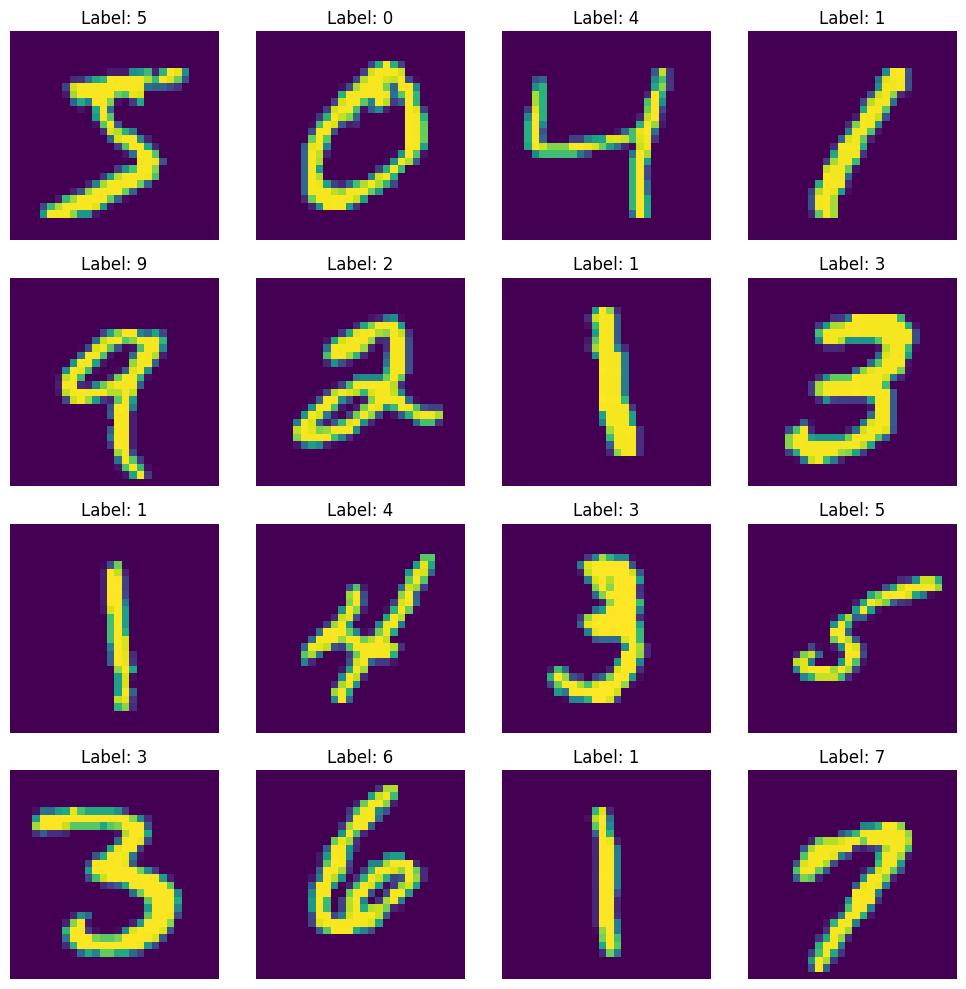

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 4, figsize=(10, 10))

for i, ax in enumerate(axes.flat):
    img = X_train[i].reshape(28, 28)  # 784 -> 28x28
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"Label: {y_train[i]}")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42

)

In [ ]:
X_train = X_train/255.0
X_test = X_test/255.0

In [ ]:
X_train

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

In [ ]:
X_test

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

In [ ]:
class CustomDataset(Dataset):

  def __init__(self, features, labels):

    # Convert to PyTorch tensors
    self.features = torch.tensor(features, dtype=torch.float32)
    self.labels = torch.tensor(labels, dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):
    return self.features[index], self.labels[index]

In [ ]:
from torch.utils.data import TensorDataset, DataLoader



In [ ]:
train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

/tmp/ipykernel_4403/932177179.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.features = torch.tensor(features, dtype=torch.float32)
/tmp/ipykernel_4403/932177179.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.labels = torch.tensor(labels, dtype=torch.long)


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 784])
torch.Size([32])


In [ ]:
class ANN(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(

            # Hidden Layer 1
            nn.Linear(784, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),

            # Hidden Layer 2
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.5),

             # Hidden Layer 3
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.5),

            # Output Layer
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.network(x)

        return x

In [ ]:
model = ANN()

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
epochs = 10

train_losses = []
val_losses = []

train_acc = []
val_acc = []

model.to(device) # Move model to GPU

for epoch in range(epochs):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images,labels in train_loader:
        images, labels = images.to(device), labels.to(device) # Move data to GPU

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs,labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _,predicted = torch.max(outputs,1)

        total += labels.size(0)

        correct += (predicted==labels).sum().item()

    train_loss = running_loss/len(train_loader)

    train_accuracy = 100*correct/total

    train_losses.append(train_loss)
    train_acc.append(train_accuracy)



    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images,labels in test_loader:
            images, labels = images.to(device), labels.to(device) # Move data to GPU

            outputs = model(images)

            loss = criterion(outputs,labels)

            running_loss += loss.item()

            _,predicted = torch.max(outputs,1)

            total += labels.size(0)

            correct += (predicted==labels).sum().item()

    val_loss = running_loss/len(test_loader)

    val_accuracy = 100*correct/total

    val_losses.append(val_loss)

    val_acc.append(val_accuracy)

    print(f"Epoch {epoch+1}/{epochs}")

    print(f"Train Loss:{train_loss:.4f} Train Acc:{train_accuracy:.2f}%")

    print(f"Val Loss:{val_loss:.4f} Val Acc:{val_accuracy:.2f}%")

Epoch 1/10
Train Loss:0.6635 Train Acc:81.44%
Val Loss:0.2245 Val Acc:93.30%
Epoch 2/10
Train Loss:0.3936 Train Acc:89.15%
Val Loss:0.1771 Val Acc:94.58%
Epoch 3/10
Train Loss:0.3340 Train Acc:90.95%
Val Loss:0.1392 Val Acc:95.67%
Epoch 4/10
Train Loss:0.2995 Train Acc:91.83%
Val Loss:0.1165 Val Acc:96.55%
Epoch 5/10
Train Loss:0.2789 Train Acc:92.50%
Val Loss:0.1136 Val Acc:96.53%
Epoch 6/10
Train Loss:0.2629 Train Acc:92.79%
Val Loss:0.1100 Val Acc:96.76%
Epoch 7/10
Train Loss:0.2466 Train Acc:93.21%
Val Loss:0.0965 Val Acc:97.10%
Epoch 8/10
Train Loss:0.2334 Train Acc:93.60%
Val Loss:0.1014 Val Acc:96.97%
Epoch 9/10
Train Loss:0.2304 Train Acc:93.50%
Val Loss:0.0918 Val Acc:97.17%
Epoch 10/10
Train Loss:0.2155 Train Acc:94.16%
Val Loss:0.0926 Val Acc:97.24%


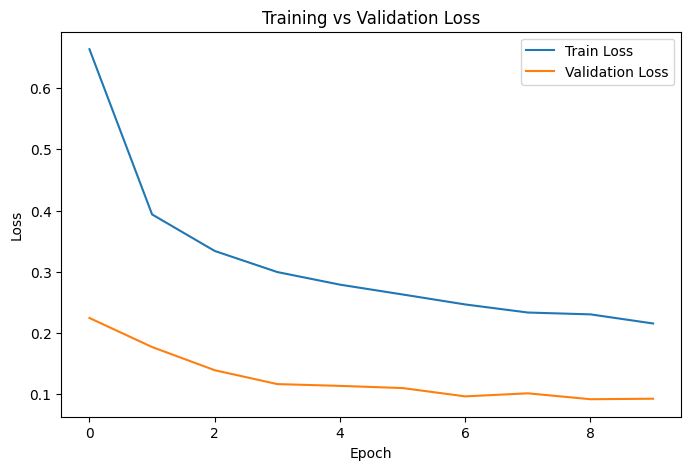

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [ ]:
model.eval()
model.to(device)

total = 0
correct = 0

with torch.no_grad():
  for xb, yb in test_loader:
    # move data to gpu
    xb, yb = xb.to(device), yb.to(device)

    outputs = model(xb)

    _, predicted = torch.max(outputs, 1)

    total = total + yb.shape[0]

    correct = correct + (predicted == yb).sum().item()

accuracy = correct/total

print(f"Test Accuracy: {accuracy*100:.2f}%")

Test Accuracy: 97.24%


## Conclusion

This notebook demonstrates the preparation of the MNIST handwritten-digit dataset for a PyTorch-based deep learning classification workflow. The dataset is normalized, converted into PyTorch tensors, checked for shape consistency, and visualized before model training.

> **Note:** Model performance metrics are intentionally not added unless they are present in the original notebook.